In [1]:
import os
import getpass

In [2]:
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "test-command"

In [3]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

def make_handoff_tool(*, agent_name: str):
    """Create a tool that can return handoff via a Command"""
    tool_name = f"transfer_to_{agent_name}"

    @tool(tool_name)
    def handoff_to_agent(
        # # optionally pass current graph state to the tool (will be ignored by the LLM)
        state: Annotated[dict, InjectedState],
        # optionally pass the current tool call ID (will be ignored by the LLM)
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Ask another agent for help."""
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": tool_name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            # navigate to another agent node in the PARENT graph
            goto=agent_name,
            graph=Command.PARENT,
            # This is the state update that the agent `agent_name` will see when it is invoked.
            # We're passing agent's FULL internal message history AND adding a tool message to make sure
            # the resulting chat history is valid. See the paragraph above for more information.
            update={"messages": state["messages"] + [tool_message]},
        )

    return handoff_to_agent

In [4]:
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b


@tool
def calender_availability(time:str):
    '''use when query related to scheduling meeting or meeting request. Get the calendar availability based on request'''
    import datetime

    current_time= datetime.datetime.now()
    # print("current time ", current_time.strftime("%Y-%m-%d"))
    
    return f"yes i'm available {time}"
    

In [5]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command

In [6]:
model = ChatAnthropic(model="claude-3-5-sonnet-latest")

open_ai_model= ChatOpenAI(model='gpt-4o-mini', temperature=0)


In [7]:
from langgraph.prebuilt import create_react_agent

addition_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="multiplication_expert")],
    state_modifier="You are an addition expert, you can ask the calendar for any help with scheduling meetings or queries regarding meetings.",
)

multiplication_expert = create_react_agent(
    model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    state_modifier="You are a multiplication expert, you can ask an addition expert for help with addition.",
)



builder = StateGraph(MessagesState)
builder.add_node("addition_expert", addition_expert)
builder.add_node("multiplication_expert", multiplication_expert)
builder.add_edge(START, "addition_expert")
graph = builder.compile()

In [8]:
from langchain_core.messages import convert_to_messages


def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [9]:
for chunk in graph.stream(
    {"messages": [("user", "what's (3 * 5) + 12")]}, subgraphs=True
):
    pretty_print_messages(chunk)

Update from subgraph addition_expert:


Update from node agent:


================================== Ai Message ==================================

[{'text': "I can help with the addition part of this expression, but I'll need help from the multiplication expert for the first part (3 * 5). Let me break this down:\n\n1. First, I'll get help to calculate 3 * 5", 'type': 'text'}, {'id': 'toolu_01AFWeJ9W5nrGy2RxLZEq7j1', 'input': {}, 'name': 'transfer_to_multiplication_expert', 'type': 'tool_use'}]
Tool Calls:
  transfer_to_multiplication_expert (toolu_01AFWeJ9W5nrGy2RxLZEq7j1)
 Call ID: toolu_01AFWeJ9W5nrGy2RxLZEq7j1
  Args:


Update from subgraph multiplication_expert:


Update from node agent:


================================== Ai Message ==================================

[{'text': 'I can help with the multiplication part! Let me calculate 3 * 5:', 'type': 'text'}, {'id': 'toolu_014PTmX7ZS6d6iyNHwR3VWaR', 'input': {'a': 3, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls

ValueError: ToolMessage.tool_call_id must match the tool call id. Expected: toolu_01TDbzgHr5ibqjTtw2n4PDni, got: toolu_01AFWeJ9W5nrGy2RxLZEq7j1 for tool 'transfer_to_addition_expert'.

In [10]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command


def make_agent(model, tools, system_prompt=None):
    model_with_tools = model.bind_tools(tools)
    tools_by_name = {tool.name: tool for tool in tools}

    def call_model(state: MessagesState) -> Command[Literal["call_tools", "__end__"]]:
        messages = state["messages"]
        if system_prompt:
            messages = [{"role": "system", "content": system_prompt}] + messages

        response = model_with_tools.invoke(messages)
        if len(response.tool_calls) > 0:
            return Command(goto="call_tools", update={"messages": [response]})

        return {"messages": [response]}

    # NOTE: this is a simplified version of the prebuilt ToolNode
    # If you want to have a tool node that has full feature parity, please refer to the source code
    def call_tools(state: MessagesState) -> Command[Literal["call_model"]]:
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for tool_call in tool_calls:
            tool_ = tools_by_name[tool_call["name"]]
            tool_input_fields = tool_.get_input_schema().model_json_schema()[
                "properties"
            ]

            # this is simplified for demonstration purposes and
            # is different from the ToolNode implementation
            if "state" in tool_input_fields:
                # inject state
                tool_call = {**tool_call, "args": {**tool_call["args"], "state": state}}

            tool_response = tool_.invoke(tool_call)
            if isinstance(tool_response, ToolMessage):
                results.append(Command(update={"messages": [tool_response]}))

            # handle tools that return Command directly
            elif isinstance(tool_response, Command):
                results.append(tool_response)

        # NOTE: nodes in LangGraph allow you to return list of updates, including Command objects
        return results

    graph = StateGraph(MessagesState)
    graph.add_node(call_model)
    graph.add_node(call_tools)
    graph.add_edge(START, "call_model")
    graph.add_edge("call_tools", "call_model")

    return graph.compile()

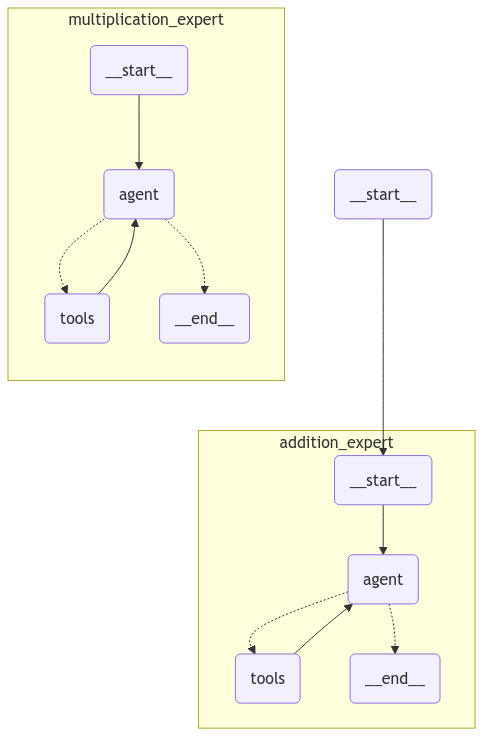

In [11]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [12]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)

In [13]:
from tools.product_enquiry import get_product_enquiry_tool
from tools.calendar import calender_availability

In [14]:
email_drafter = make_agent(
    open_ai_model,
    [get_product_enquiry_tool(), make_handoff_tool(agent_name="calendar_agent")],
    system_prompt="You are an email drafter expert, you can ask an calendar_agent  for help with enquires and scheduling regarding meetings.",
)
multiplication_expert = make_agent(
    open_ai_model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    system_prompt="You are a multiplication expert, you can ask an addition expert for help with addition.",
)

calendar_agent= make_agent(
    open_ai_model,
    
    [calender_availability, make_handoff_tool(agent_name="email_drafter")],
    system_prompt="You are expert with any help with scheduling meetings or queries regarding meetings, ask email_drafter for any help with product enquiry "
    )

builder = StateGraph(MessagesState)
builder.add_node("email_drafter", email_drafter)
builder.add_node("calendar_agent", calendar_agent)
builder.add_edge(START, "email_drafter")
graph_2 = builder.compile()

called product enquiry tool


d:\innovizeai\code-sapien\inbox-manager\utils.py:22: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-qdrant package and should be used instead. To use it run `pip install -U :class:`~langchain-qdrant` and import as `from :class:`~langchain_qdrant import Qdrant``.
  qd = Qdrant(client, collection_name, embeddings)
d:\innovizeai\code-sapien\inbox-manager\tools\product_enquiry.py:35: LangChainBetaWarning: This API is in beta and may change in the future.
  return product_enquiry_tool.as_tool()


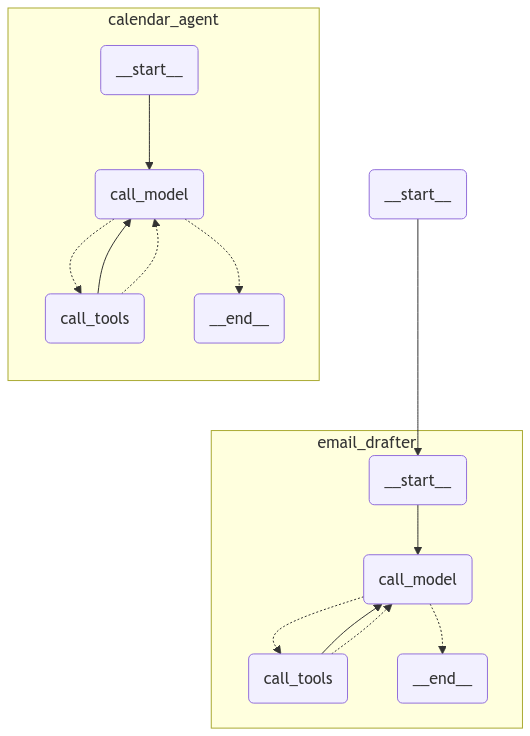

In [15]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph_2.get_graph(xray=1).draw_mermaid_png()))

In [16]:
for chunk in graph_2.stream(
    {"messages": [("user", " please share some casestudies in finance and are you available next week for a quick call? ")]}, subgraphs=True
):
    pretty_print_messages(chunk)

Update from subgraph email_drafter:


Update from node call_model:


================================== Ai Message ==================================
Tool Calls:
  product_enquiry (call_4EUeGjxrLdmI89QIBUVQuJwA)
 Call ID: call_4EUeGjxrLdmI89QIBUVQuJwA
  Args:
    query: case studies in finance
  transfer_to_calendar_agent (call_6SodhA2HQY5J0d9eGcIcz1LB)
 Call ID: call_6SodhA2HQY5J0d9eGcIcz1LB
  Args:




BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_4EUeGjxrLdmI89QIBUVQuJwA", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

In [ ]:
agent = make_agent(model, [add, multiply])

for chunk in agent.stream({"messages": [("user", "what's (3 * 5) + 12")]}):
    pretty_print_messages(chunk)